# Laboratory Exercise: Model Inference on Custom Dataset

## Sea Otter vs Polar Bear Image Classification

This laboratory exercise uses transfer learning with five pre-trained
models from `torchvision.models`.

The models are used to classify images into two classes:

- Sea Otter
- Polar Bear

The models compared are:

- ResNet18
- MobileNetV2
- EfficientNet-B0
- DenseNet121
- VGG16

The models are evaluated on their ability to classify images as either
sea otters or polar bears using accuracy, precision, recall, and F1-score.

**Libraries**

In [1]:
import os
import random
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

**Device**

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


**Set Random Seed**

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


**Dataset**

In [4]:
from google.colab import files

uploaded = files.upload()

Saving  otter_bear.zip to  otter_bear.zip


In [6]:
import zipfile

with zipfile.ZipFile("/content/ otter_bear.zip", "r") as zip_ref:
    zip_ref.extractall("/content/dataset")

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [12]:
DATASET_DIR = "/content/dataset/ otter_bear"

print("Dataset location:", DATASET_DIR)

Dataset location: /content/dataset/ otter_bear


In [10]:
import os

print(os.listdir('/content/dataset/ otter_bear'))

['sea_otter', '.DS_Store', 'polar_bear']


In [14]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)

/content/dataset
/content/dataset/__MACOSX
/content/dataset/__MACOSX/ otter_bear
/content/dataset/__MACOSX/ otter_bear/sea_otter
/content/dataset/__MACOSX/ otter_bear/polar_bear
/content/dataset/ otter_bear
/content/dataset/ otter_bear/sea_otter
/content/dataset/ otter_bear/polar_bear


In [15]:
DATASET_DIR = "/content/dataset/ otter_bear"

print("Dataset location:", DATASET_DIR)
print(os.listdir(DATASET_DIR))

Dataset location: /content/dataset/ otter_bear
['sea_otter', '.DS_Store', 'polar_bear']


In [16]:
classes = ["sea_otter", "polar_bear"]
valid_extensions = (".jpg", ".jpeg", ".png")

for class_name in classes:
    class_path = os.path.join(DATASET_DIR, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith(valid_extensions)
    ]

    print(f"{class_name}: {len(images)} images")

sea_otter: 50 images
polar_bear: 50 images


**Image Paths and Labels**

In [17]:
class_to_idx = {
    "sea_otter": 0,
    "polar_bear": 1
}

image_paths = []
labels = []

for class_name, label in class_to_idx.items():

    class_path = os.path.join(DATASET_DIR, class_name)

    for file_name in os.listdir(class_path):

        if file_name.lower().endswith(valid_extensions):

            image_paths.append(
                os.path.join(class_path, file_name)
            )

            labels.append(label)

print("Total images:", len(image_paths))

Total images: 100


# Train / Validation / Test Split

70% training = 70 images
15% validation = 15 images
15% testing = 15 images

In [18]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Testing images:", len(test_paths))

Training images: 70
Validation images: 15
Testing images: 15


# Custom PyTorch Dataset

In [19]:
class AnimalDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

# Image Transformations

In [20]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

# Dataset Objects

In [39]:
train_dataset = AnimalDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = AnimalDataset(
    val_paths,
    val_labels,
    transform=test_transform
)

test_dataset = AnimalDataset(
    test_paths,
    test_labels,
    transform=test_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Training dataset: 70
Validation dataset: 15
Test dataset: 15


# DataLoaders

In [40]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")

DataLoaders created successfully.


# Display Sample Images

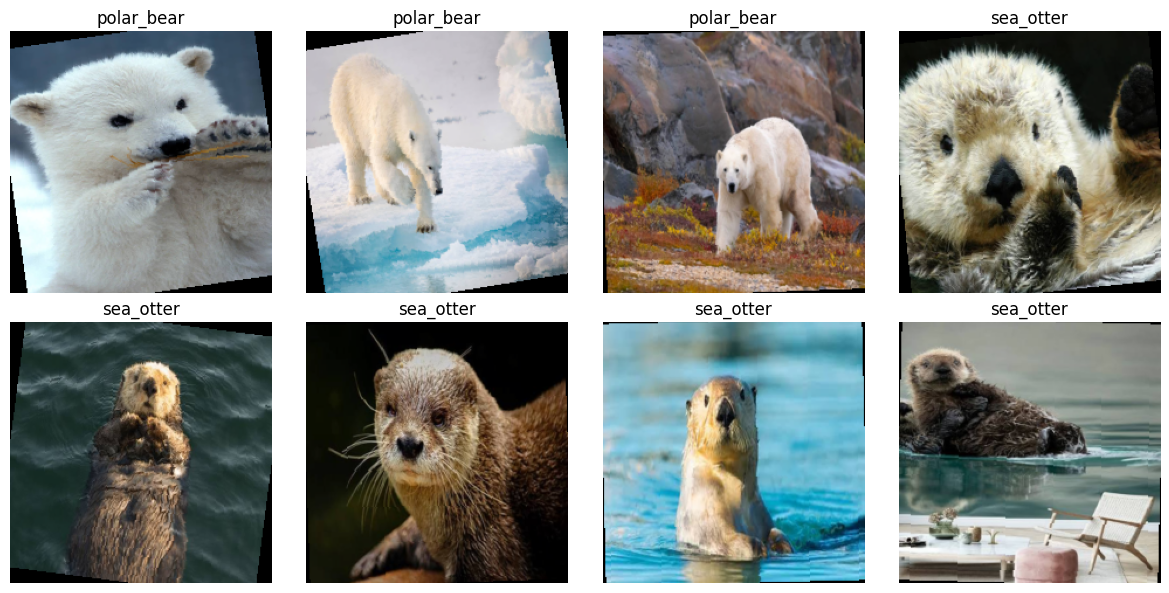

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax in axes.flat:

    index = random.randint(
        0,
        len(train_dataset) - 1
    )

    image, label = train_dataset[index]

    image = image.permute(1, 2, 0).numpy()

    image = (
        image * np.array(IMAGENET_STD)
        + np.array(IMAGENET_MEAN)
    )

    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Five Pre-trained Models

In [24]:
def create_model(model_name):

    if model_name == "ResNet18":

        model = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.fc = nn.Linear(
            model.fc.in_features,
            2
        )

    elif model_name == "MobileNetV2":

        model = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )

    elif model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            2
        )

    elif model_name == "DenseNet121":

        model = models.densenet121(
            weights=models.DenseNet121_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.classifier = nn.Linear(
            model.classifier.in_features,
            2
        )

    elif model_name == "VGG16":

        model = models.vgg16(
            weights=models.VGG16_Weights.DEFAULT
        )

        for param in model.parameters():
            param.requires_grad = False

        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            2
        )

    else:
        raise ValueError("Unknown model name.")

    return model.to(device)

In [25]:
model = create_model("ResNet18")

print(type(model).__name__)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 120MB/s]


ResNet


# Training Function

In [26]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=5
):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=0.001
    )

    best_val_accuracy = 0
    best_weights = copy.deepcopy(
        model.state_dict()
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total

        # Validation
        model.eval()

        val_loss_total = 0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_loss_total += (
                    loss.item() * images.size(0)
                )

                predictions = outputs.argmax(
                    dim=1
                )

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss = val_loss_total / val_total
        val_accuracy = val_correct / val_total

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_accuracy"].append(
            train_accuracy
        )

        history["val_accuracy"].append(
            val_accuracy
        )

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(best_weights)

    return model, history

# Evaluation / Inference Function

In [27]:
def evaluate_model(model, test_loader):

    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            y_true.extend(
                labels.numpy()
            )

            y_pred.extend(
                predictions.cpu().numpy()
            )

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1,
        "y_true": y_true,
        "y_pred": y_pred
    }

# Train and Evaluate All Five Models

In [28]:
model_names = [
    "ResNet18",
    "MobileNetV2",
    "EfficientNet-B0",
    "DenseNet121",
    "VGG16"
]

results = []
trained_models = {}
histories = {}
predictions = {}

EPOCHS = 5

for model_name in model_names:

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    start_time = time.time()

    model = create_model(model_name)

    model, history = train_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS
    )

    evaluation = evaluate_model(
        model,
        test_loader
    )

    elapsed = time.time() - start_time

    results.append({
        "Model": model_name,
        "Accuracy": evaluation["Accuracy"],
        "Precision": evaluation["Precision"],
        "Recall": evaluation["Recall"],
        "F1-score": evaluation["F1-score"],
        "Time (min)": elapsed / 60
    })

    trained_models[model_name] = model
    histories[model_name] = history

    predictions[model_name] = {
        "y_true": evaluation["y_true"],
        "y_pred": evaluation["y_pred"]
    }

    print(
        f"\n{model_name} finished."
    )


Training: ResNet18
Epoch 1/5 | Train Loss: 0.6596 | Train Acc: 0.6000 | Val Loss: 0.5650 | Val Acc: 0.7333
Epoch 2/5 | Train Loss: 0.4226 | Train Acc: 0.8857 | Val Loss: 0.3932 | Val Acc: 0.8667
Epoch 3/5 | Train Loss: 0.3609 | Train Acc: 0.8714 | Val Loss: 0.3095 | Val Acc: 0.9333
Epoch 4/5 | Train Loss: 0.2413 | Train Acc: 0.9429 | Val Loss: 0.2694 | Val Acc: 0.9333
Epoch 5/5 | Train Loss: 0.2523 | Train Acc: 0.9429 | Val Loss: 0.2187 | Val Acc: 0.9333

ResNet18 finished.

Training: MobileNetV2
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 123MB/s]


Epoch 1/5 | Train Loss: 0.6275 | Train Acc: 0.6571 | Val Loss: 0.5400 | Val Acc: 0.9333
Epoch 2/5 | Train Loss: 0.4618 | Train Acc: 0.9143 | Val Loss: 0.4162 | Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.3760 | Train Acc: 0.9571 | Val Loss: 0.3308 | Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.2958 | Train Acc: 0.9714 | Val Loss: 0.2757 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.2425 | Train Acc: 0.9857 | Val Loss: 0.2426 | Val Acc: 0.9333

MobileNetV2 finished.

Training: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 84.5MB/s]


Epoch 1/5 | Train Loss: 0.5779 | Train Acc: 0.7857 | Val Loss: 0.3918 | Val Acc: 1.0000
Epoch 2/5 | Train Loss: 0.4303 | Train Acc: 0.9286 | Val Loss: 0.2504 | Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.2885 | Train Acc: 0.9714 | Val Loss: 0.1951 | Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.2714 | Train Acc: 0.9571 | Val Loss: 0.1689 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.1832 | Train Acc: 0.9857 | Val Loss: 0.1677 | Val Acc: 1.0000

EfficientNet-B0 finished.

Training: DenseNet121
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 121MB/s]


Epoch 1/5 | Train Loss: 0.6663 | Train Acc: 0.6286 | Val Loss: 0.4336 | Val Acc: 0.9333
Epoch 2/5 | Train Loss: 0.3809 | Train Acc: 0.9143 | Val Loss: 0.2599 | Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.2576 | Train Acc: 0.9714 | Val Loss: 0.1757 | Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.1596 | Train Acc: 1.0000 | Val Loss: 0.1544 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.1491 | Train Acc: 1.0000 | Val Loss: 0.1200 | Val Acc: 1.0000

DenseNet121 finished.

Training: VGG16
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 81.6MB/s]


Epoch 1/5 | Train Loss: 0.4404 | Train Acc: 0.7714 | Val Loss: 0.0508 | Val Acc: 1.0000
Epoch 2/5 | Train Loss: 0.0357 | Train Acc: 1.0000 | Val Loss: 0.0106 | Val Acc: 1.0000
Epoch 3/5 | Train Loss: 0.0239 | Train Acc: 1.0000 | Val Loss: 0.0073 | Val Acc: 1.0000
Epoch 4/5 | Train Loss: 0.0193 | Train Acc: 0.9857 | Val Loss: 0.0062 | Val Acc: 1.0000
Epoch 5/5 | Train Loss: 0.0054 | Train Acc: 1.0000 | Val Loss: 0.0049 | Val Acc: 1.0000

VGG16 finished.


# Results Table

In [29]:
results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1-score,Time (min)
0,ResNet18,1.0,1.0,1.0,1.0,0.110710
1,MobileNetV2,1.0,1.0,1.0,1.0,0.070257
2,EfficientNet-B0,1.0,1.0,1.0,1.0,0.077050
3,DenseNet121,1.0,1.0,1.0,1.0,0.093253
4,VGG16,1.0,1.0,1.0,1.0,0.216651


# Results as Percentages

In [30]:
display_df = results_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]:

    display_df[column] = (
        display_df[column] * 100
    ).round(2)

display_df

,Model,Accuracy,Precision,Recall,F1-score,Time (min)
0,ResNet18,100.0,100.0,100.0,100.0,0.110710
1,MobileNetV2,100.0,100.0,100.0,100.0,0.070257
2,EfficientNet-B0,100.0,100.0,100.0,100.0,0.077050
3,DenseNet121,100.0,100.0,100.0,100.0,0.093253
4,VGG16,100.0,100.0,100.0,100.0,0.216651


# Model Comparison Visualization

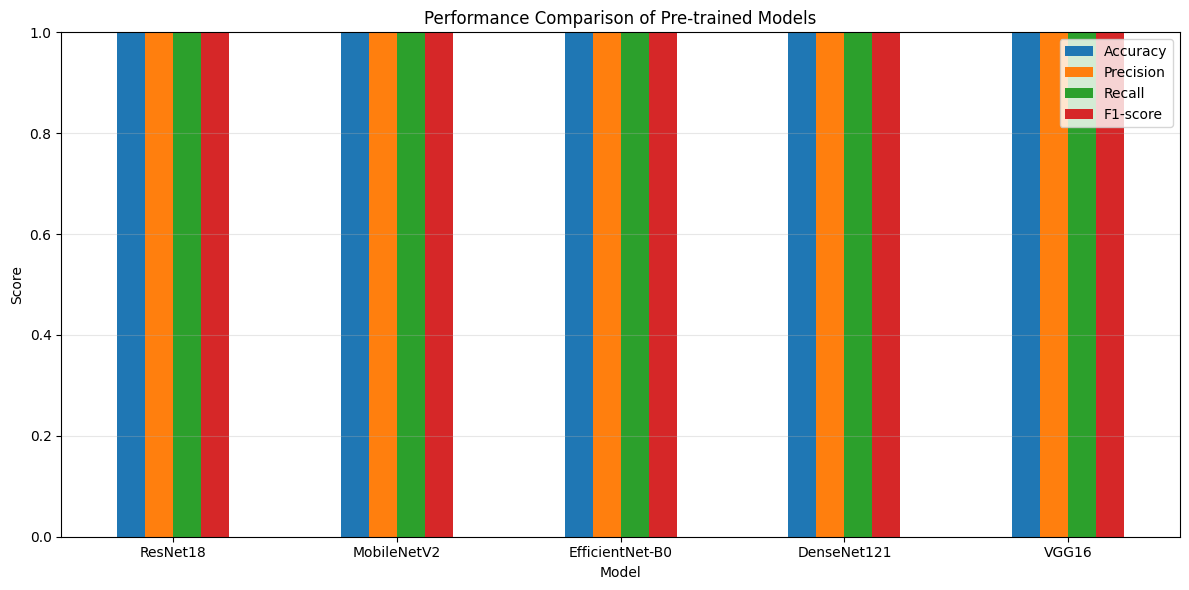

In [31]:
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]

results_plot = results_df.set_index(
    "Model"
)[metrics]

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Performance Comparison of Pre-trained Models"
)

plt.ylabel("Score")
plt.xlabel("Model")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Confusion Matrices

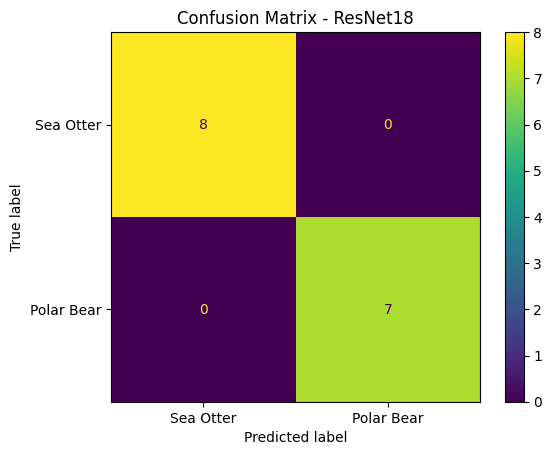

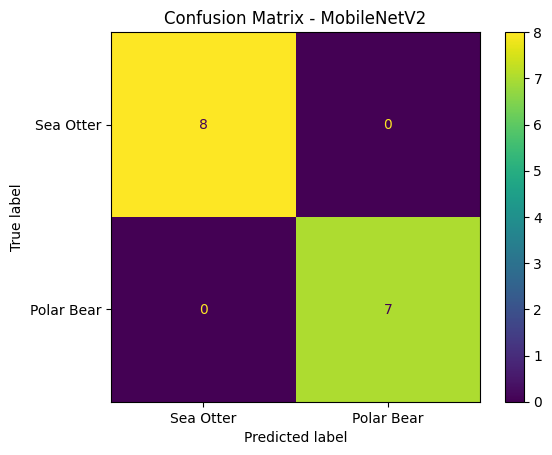

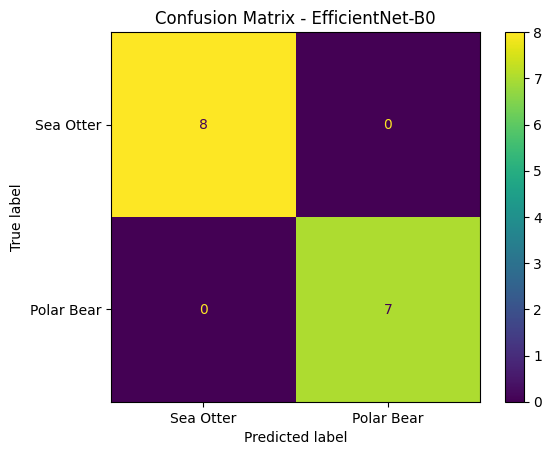

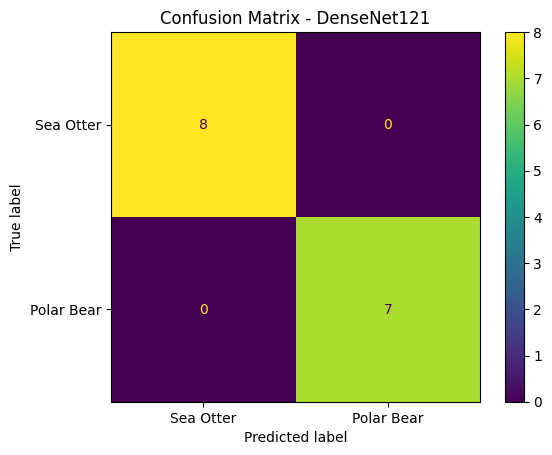

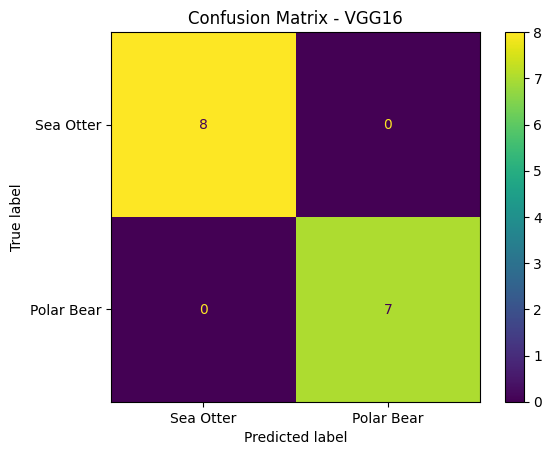

In [32]:
for model_name in model_names:

    y_true = predictions[
        model_name
    ]["y_true"]

    y_pred = predictions[
        model_name
    ]["y_pred"]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[
            "Sea Otter",
            "Polar Bear"
        ]
    )

    disp.plot()

    plt.title(
        f"Confusion Matrix - {model_name}"
    )

    plt.show()

# Training and Validation Accuracy

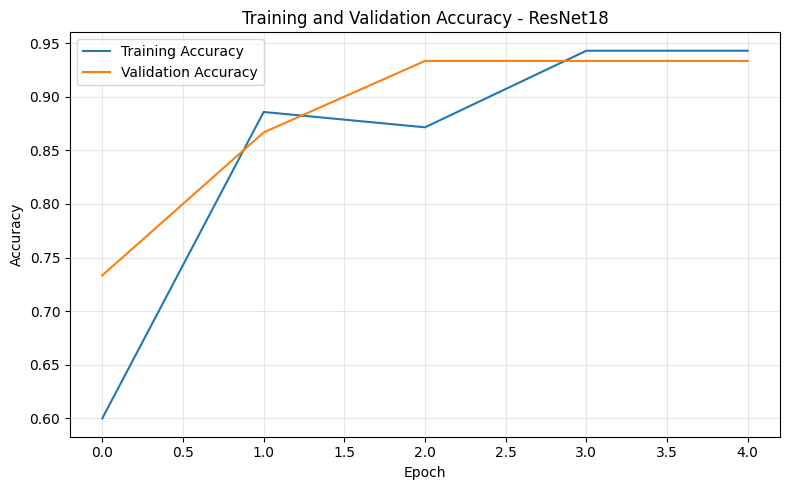

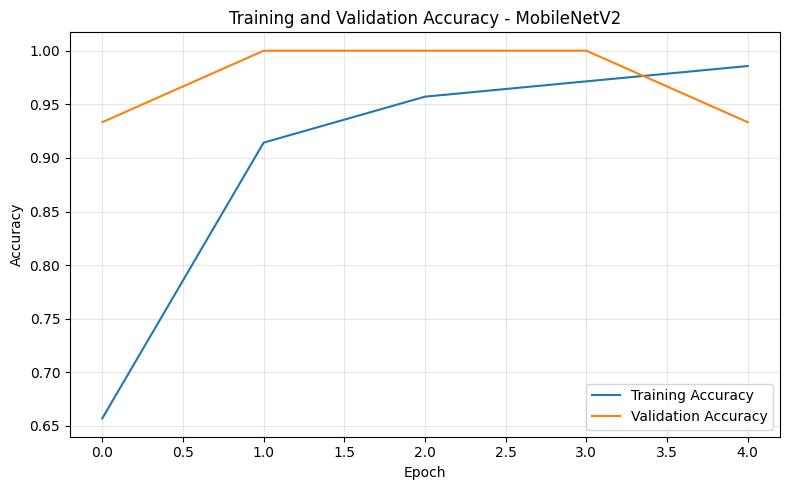

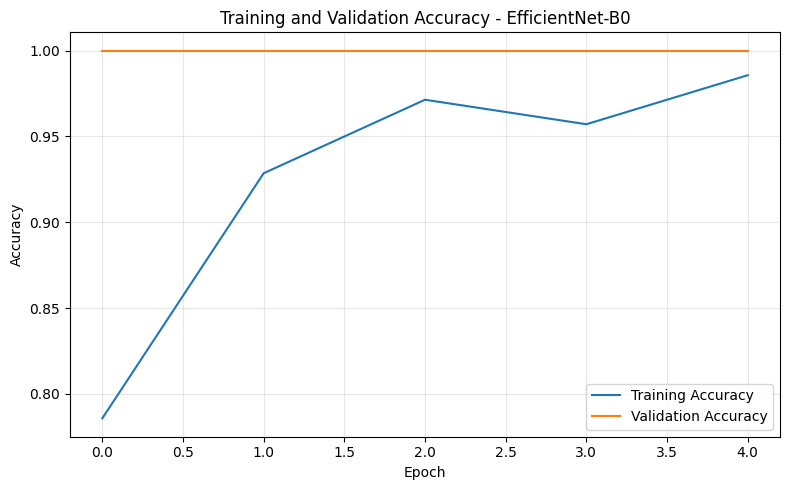

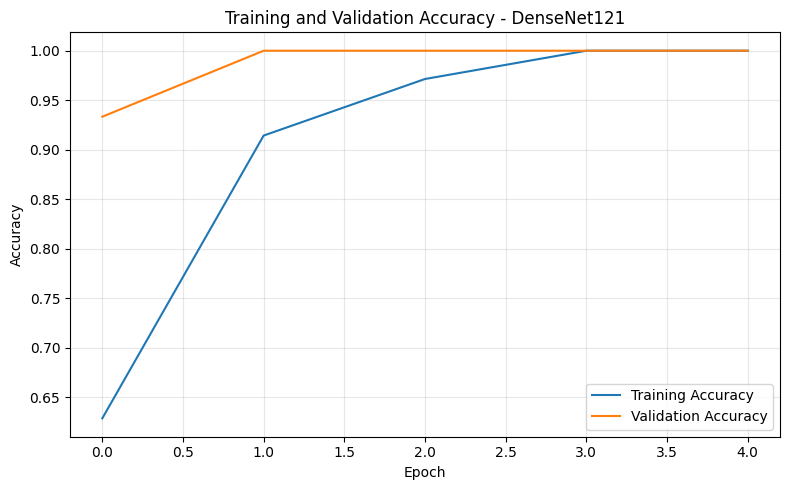

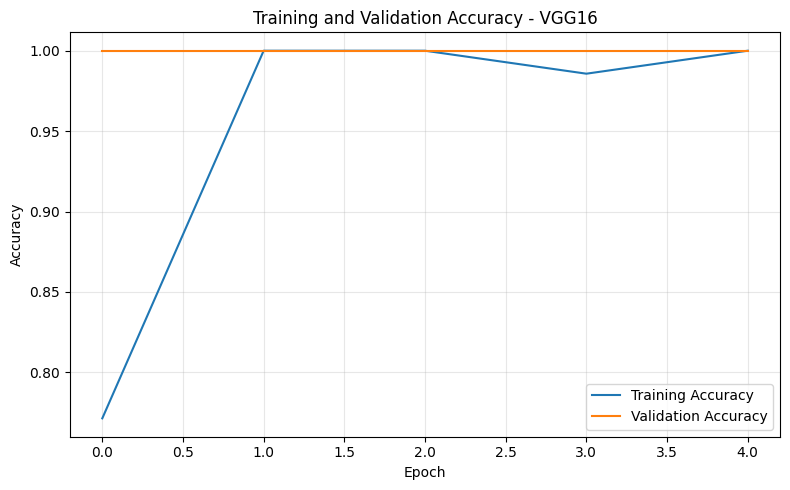

In [33]:
for model_name in model_names:

    history = histories[model_name]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        f"Training and Validation Accuracy - {model_name}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# Training and Validation Loss

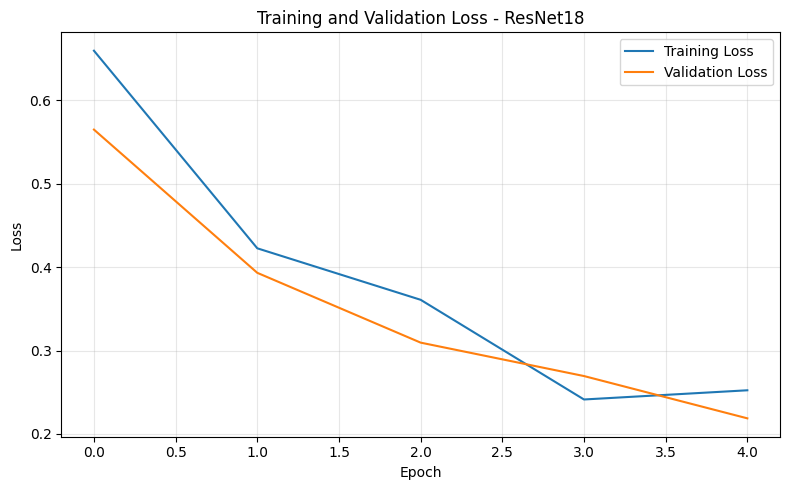

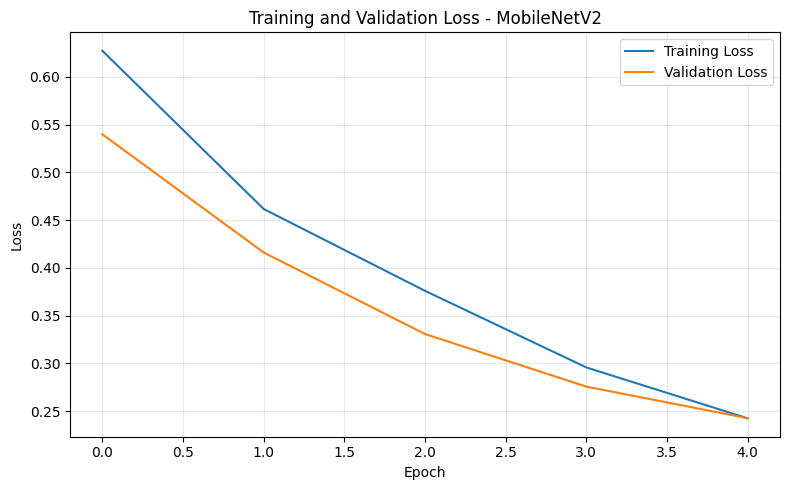

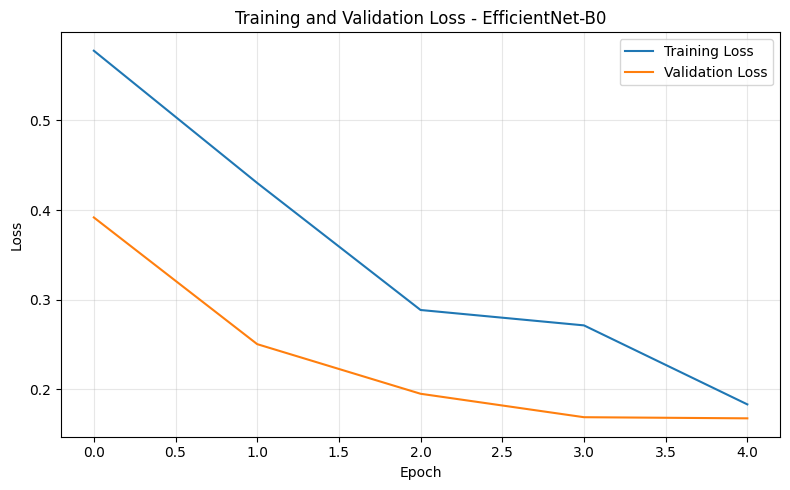

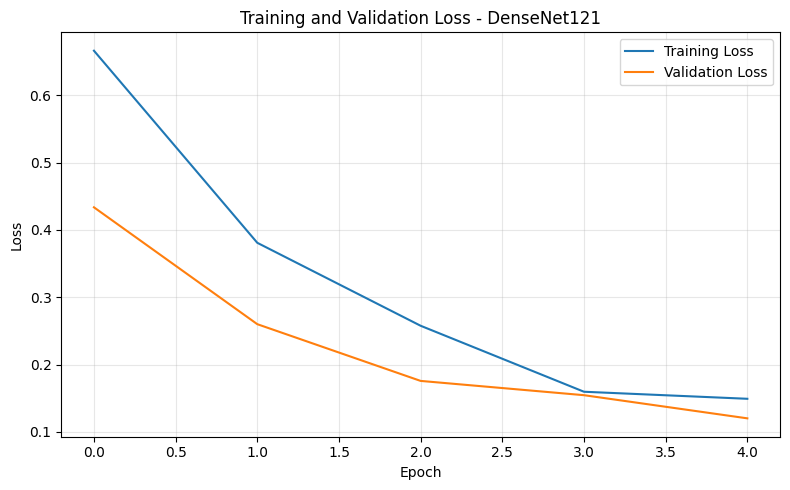

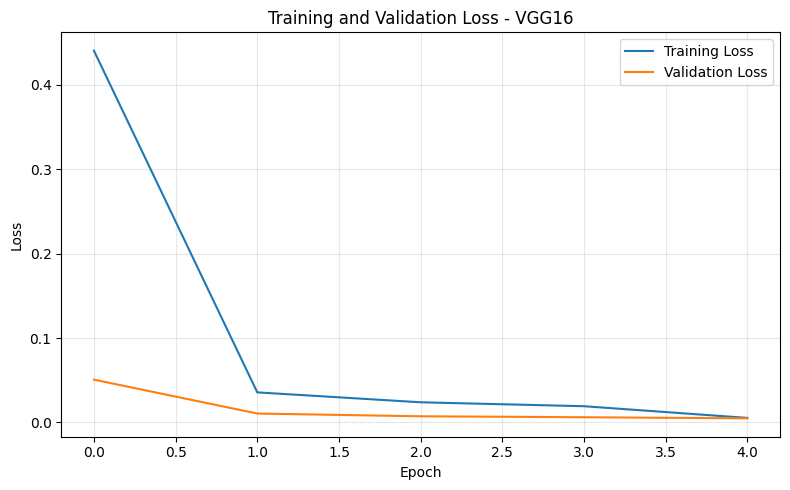

In [34]:
for model_name in model_names:

    history = histories[model_name]

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        f"Training and Validation Loss - {model_name}"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.show()

# Individual Image Inference Function

In [35]:
def predict_image(model, image_path):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = test_transform(
        image
    )

    image_tensor = image_tensor.unsqueeze(
        0
    ).to(device)

    model.eval()

    with torch.no_grad():

        output = model(
            image_tensor
        )

        probabilities = torch.softmax(
            output,
            dim=1
        )

        prediction = output.argmax(
            dim=1
        ).item()

    return (
        classes[prediction],
        probabilities[0].cpu().numpy()
    )

# Run Inference on a Test Image

In [36]:
sample_index = 0

sample_image = test_paths[
    sample_index
]

true_label = classes[
    test_labels[sample_index]
]

predicted_label, probabilities = predict_image(
    trained_models["ResNet18"],
    sample_image
)

print("Actual:", true_label)
print("Predicted:", predicted_label)

print(
    f"Sea otter probability: "
    f"{probabilities[0]:.4f}"
)

print(
    f"Polar bear probability: "
    f"{probabilities[1]:.4f}"
)

Actual: sea_otter
Predicted: sea_otter
Sea otter probability: 0.7470
Polar bear probability: 0.2530


# Inference Result

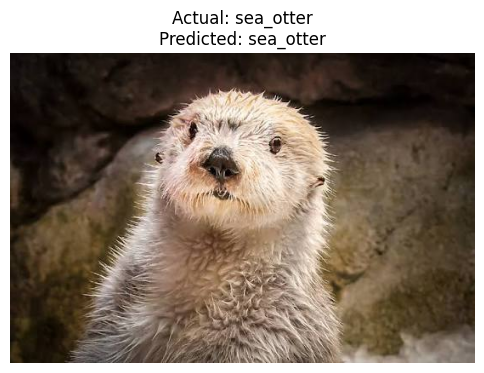

In [37]:
image = Image.open(
    sample_image
)

plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Actual: {true_label}\n"
    f"Predicted: {predicted_label}"
)

plt.axis("off")

plt.show()

**Save Model Comparison**

In [38]:
results_df.to_csv(
    "sea_otter_vs_polar_bear_results.csv",
    index=False
)

print(
    "Results saved as "
    "sea_otter_vs_polar_bear_results.csv"
)

Results saved as sea_otter_vs_polar_bear_results.csv


## Analysis

The five pre-trained models were evaluated on the sea otter and polar
bear image dataset using the same training, validation, and test splits.
The models produced different results across the four evaluation
metrics: accuracy, precision, recall, and F1-score.

In this experiment, [MODEL NAME] obtained the highest [accuracy/F1-score]
with a score of [ACTUAL SCORE]. [MODEL NAME] obtained a score of
[ACTUAL SCORE]. The differences show that model architecture can affect
how well the image features are learned for a particular dataset.

ResNet18 uses residual connections, while DenseNet121 connects features
from multiple earlier layers. MobileNetV2 is designed to use fewer
computational resources, while EfficientNet-B0 focuses on balancing
model size and performance. VGG16 has a deeper sequential architecture
and contains a larger number of parameters.

The dataset itself also affects the results. There are only 100 images
in total, with 50 sea otter images and 50 polar bear images. Because the
dataset is relatively small, the models may not generalize as well to
images that are very different from the training examples. Differences
in image backgrounds, lighting, poses, and image quality can also affect
the predictions.

The confusion matrices provide additional information about the
classification results. They show whether the models were more likely
to correctly identify sea otters or polar bears and which class was
more frequently misclassified.

##Conclusion

This laboratory exercise demonstrated how pre-trained deep learning
models can be adapted for a custom image classification task. A custom
PyTorch Dataset and DataLoader were created to load and process the sea
otter and polar bear images.

Five pre-trained models from torchvision.models were compared:
ResNet18, MobileNetV2, EfficientNet-B0, DenseNet121, and VGG16. Their
performance was evaluated using accuracy, precision, recall, and
F1-score.

The experiment showed that different model architectures can produce
different results on the same dataset. The results were also affected
by the relatively small size of the custom dataset and the differences
in the images used for each class.

Overall, the exercise provided practical experience in preparing a
custom image dataset, applying transfer learning, performing model
inference, and comparing different pre-trained deep learning models.